# Step 3_v2 - Dataset Understanding and EDA

**Note**: This notebook extends the initial Step 3 EDA **after exact image duplicates and provenance issues were identified**. It documents the additional data-quality analysis, deduplication process and revised train/validation/test splitting strategy.

In [7]:
from pathlib import Path
import sys
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

def find_project_root(start: Path) -> Path:
    """Find the repository root from either the project or notebooks folder."""
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "__init__.py").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError(
        "Could not find the project root. Open this notebook from the "
        "grapevine_disease_classification repository."
    )

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src import RANDOM_SEED

# Local dataset directory containing the four class folders
DATA_DIR = PROJECT_ROOT / "data" / "raw" / "GVLiD"
CLASS_NAMES = [
    "Black rot",
    "esca",
    "healthy",
    "leaf blight",
]

np.random.seed(RANDOM_SEED)

# Confirm that the local dataset directory is available
print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_DIR.resolve())
print("Dataset directory exists:", DATA_DIR.exists())

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR}")

Project root: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification
Dataset path: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/raw/GVLiD
Dataset directory exists: True


## Dataset loading

The dataset is loaded from the local raw-data directory to confirm that it is available and that the class folders correspond to the four target labels defined for the image-classification task.

In [8]:
# Identify the class folders available in the local dataset
class_folders = sorted([
    folder.name
    for folder in DATA_DIR.iterdir()
    if folder.is_dir() and folder.name != "docs"
])

print("Class folders found:", class_folders)
print("Number of classes:", len(class_folders))

# Check whether the local folders match the expected target classes
print("Expected classes:", sorted(CLASS_NAMES))
print("Class folders match expected classes:", class_folders == sorted(CLASS_NAMES))

Class folders found: ['Black rot', 'esca', 'healthy', 'leaf blight']
Number of classes: 4
Expected classes: ['Black rot', 'esca', 'healthy', 'leaf blight']
Class folders match expected classes: True


### Conclusion

The local dataset was successfully loaded and contains the four expected target classes: **Black rot, Esca, Healthy, and Leaf blight**. The folder structure matches the target labels defined for the project, confirming that the dataset is correctly organised for a supervised multiclass image-classification task.

## Dataset structure

The dataset structure is examined to verify the class folders, image file formats and integrity of the raw data before further analysis.

In [9]:
# Inspect the number and format of image files in each class folder
image_extensions = {".jpg", ".jpeg", ".png"}

structure_summary = []

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    all_files = [f for f in class_dir.iterdir() if f.is_file()]
    image_files = [f for f in all_files if f.suffix.lower() in image_extensions]
    non_image_files = [f for f in all_files if f.suffix.lower() not in image_extensions]

    structure_summary.append({
        "Class": class_name,
        "Total files": len(all_files),
        "Image files": len(image_files),
        "Non-image files": len(non_image_files)
    })

structure_df = pd.DataFrame(structure_summary)

print("Dataset structure:")
display(structure_df)

print("\nTotal image files:", structure_df["Image files"].sum())

Dataset structure:


,Class,Total files,Image files,Non-image files
0,Black rot,808,808,0
1,esca,888,888,0
2,healthy,1109,1109,0
3,leaf blight,672,672,0



Total image files: 3477


### Conclusion

The dataset contains **3,477 image files** distributed across four class folders:

- Black rot: 808 images
- Esca: 888 images
- Healthy: 1,109 images
- Leaf blight: 672 images

All files contained in the class folders are recognised image files, with no unexpected non-image files identified. The raw dataset remains organised by class and has not been modified at this stage.

## Class distribution

The distribution of images across the four target classes is analysed to identify potential class imbalance that may affect model training and evaluation.

,Class,Image files,Percentage
0,Black rot,808,23.24
1,esca,888,25.54
2,healthy,1109,31.90
3,leaf blight,672,19.33


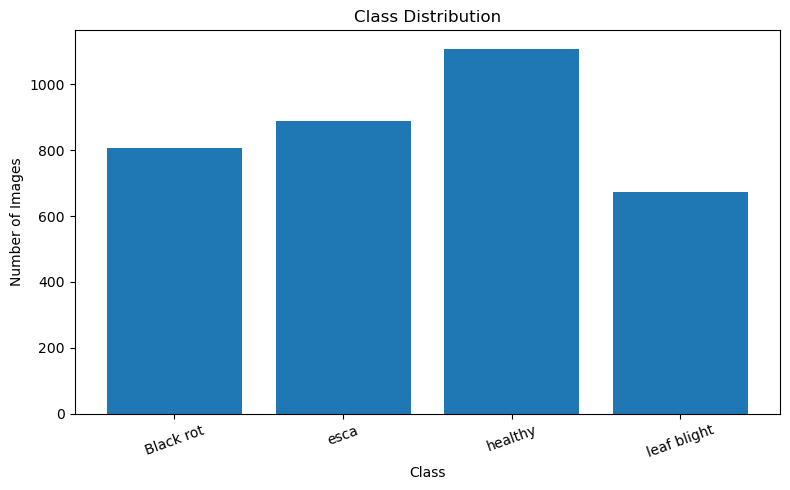

In [10]:
# Calculate the class distribution
class_distribution = structure_df[["Class", "Image files"]].copy()

total_images = class_distribution["Image files"].sum()

class_distribution["Percentage"] = (
    class_distribution["Image files"] / total_images * 100
).round(2)

display(class_distribution)

# Visualise the number of images in each class
plt.figure(figsize=(8, 5))
plt.bar(
    class_distribution["Class"],
    class_distribution["Image files"]
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Conclusion

The dataset shows a **moderate class imbalance**. Healthy is the most represented class (31.90%), while Leaf blight is the least represented (19.33%). Esca (25.54%) and Black rot (23.24%) fall between these two.

The imbalance is not severe, but it should be considered during model evaluation. Overall accuracy alone may hide differences in performance between classes. Therefore, class-level performance and the confusion matrix should also be examined during the evaluation stage.

## Image dimensions

The image dimensions and colour mode are examined to assess their consistency across the dataset and identify preprocessing requirements for the CNN modelling stage.

In [11]:
# Inspect image dimensions and colour mode across the full dataset
image_properties = []

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    for image_path in class_dir.glob("*.jpg"):
        with Image.open(image_path) as img:
            image_properties.append({
                "Class": class_name,
                "Width": img.width,
                "Height": img.height,
                "Mode": img.mode
            })

image_properties_df = pd.DataFrame(image_properties)

print("Number of images inspected:", len(image_properties_df))

print("\nImage dimensions:")
display(
    image_properties_df[["Width", "Height"]]
    .value_counts()
    .reset_index(name="Count")
)

print("\nImage colour modes:")
display(
    image_properties_df["Mode"]
    .value_counts()
    .reset_index(name="Count")
)

Number of images inspected: 3477

Image dimensions:


,Width,Height,Count
0,1080,1080,3477



Image colour modes:


,Mode,Count
0,RGB,3477


### Conclusion

All **3,477 images** were inspected and have consistent dimensions of **1080 × 1080 pixels** and **RGB colour mode**.

This consistency simplifies the preprocessing pipeline because there are no differences in image dimensions or colour channels that need to be corrected. However, the original 1080 × 1080 resolution is relatively large for CNN training. The images should therefore be resized to the input dimensions selected for the CNN during the modelling stage, balancing computational efficiency with preservation of relevant visual information.

## Example images by class

Representative images from each class are visually examined to assess variability in lighting, background, orientation, scale and symptom appearance, as well as potential visual similarities between disease classes.

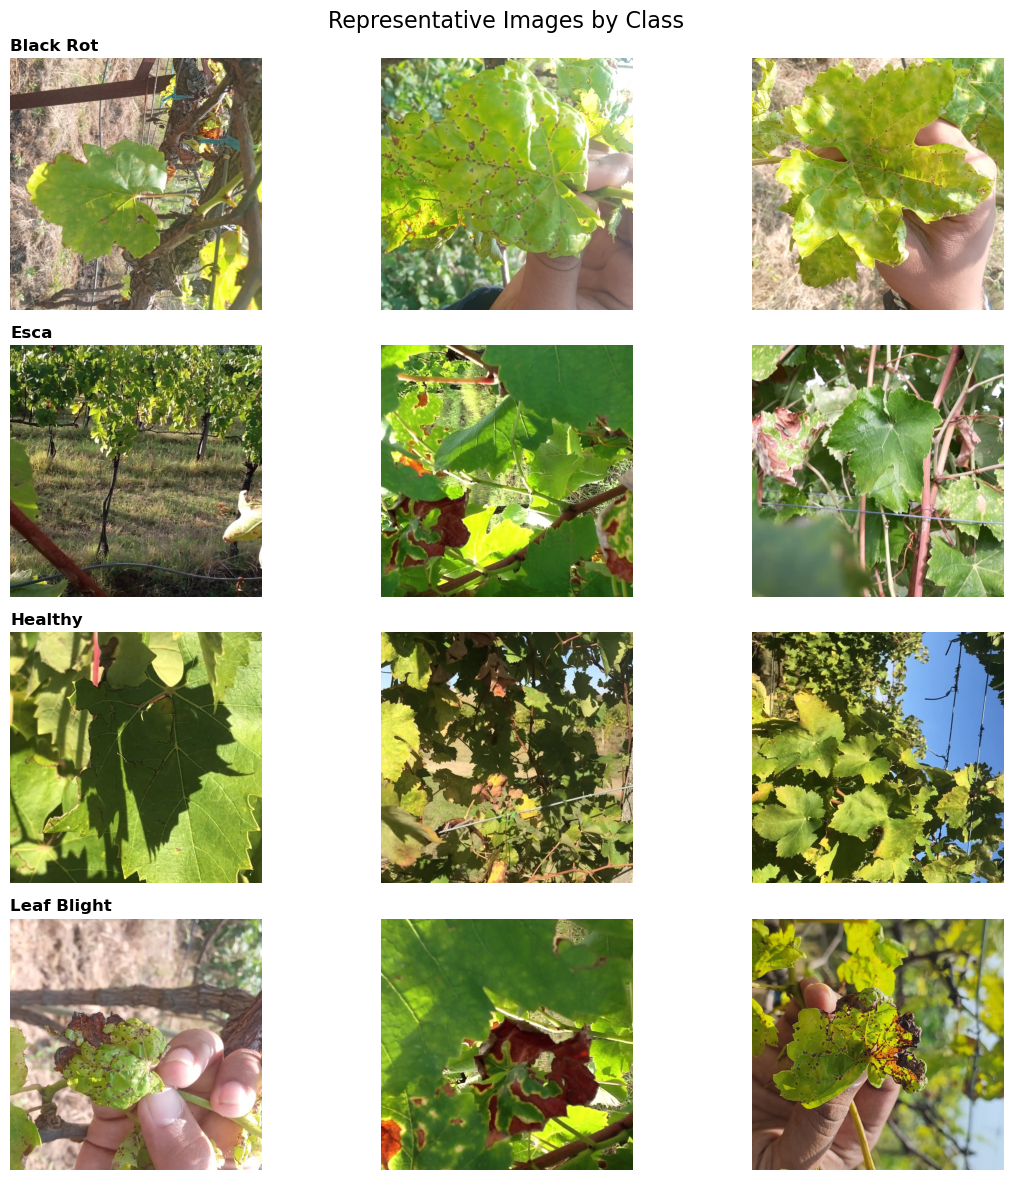

In [12]:
# Display representative random images from each class
n_samples = 3

fig, axes = plt.subplots(
    len(CLASS_NAMES),
    n_samples,
    figsize=(12, 12)
)

for row, class_name in enumerate(CLASS_NAMES):
    class_dir = DATA_DIR / class_name
    image_files = sorted(class_dir.glob("*.jpg"))

    selected_images = np.random.choice(
        image_files,
        size=n_samples,
        replace=False
    )

    for col, image_path in enumerate(selected_images):
        with Image.open(image_path) as img:
            axes[row, col].imshow(img)

        axes[row, col].axis("off")

        # Display the class name above the first image in each row
        if col == 0:
            axes[row, col].set_title(
                class_name.title(),
                fontsize=12,
                fontweight="bold",
                loc="left"
            )

plt.suptitle(
    "Representative Images by Class",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Conclusion

The visual inspection shows substantial real-world variability in the dataset. Images differ in **leaf orientation, scale, lighting and background**, ranging from close-up views of individual leaves to wider vineyard scenes. Backgrounds may include other leaves, branches, soil, sky, vineyard structures and hands.

Disease symptoms also vary in appearance and extent, while some classes show potentially similar visual patterns, such as brown or necrotic areas. These characteristics make the classification task more challenging but also more representative of field conditions.

The model should therefore learn relevant visual features from the leaves and disease symptoms rather than relying on consistent backgrounds or image composition.

## Data quality checks

Basic data quality checks are performed to identify unreadable images, unexpected file formats and duplicate filenames that could affect subsequent preprocessing or modelling.

In [13]:
# Perform basic data quality checks
unreadable_files = []
unexpected_formats = []
all_filenames = []

valid_extensions = {".jpg", ".jpeg", ".png"}

for class_name in CLASS_NAMES:
    class_dir = DATA_DIR / class_name

    for file_path in class_dir.iterdir():
        if not file_path.is_file():
            continue

        all_filenames.append(file_path.name)

        # Check file format
        if file_path.suffix.lower() not in valid_extensions:
            unexpected_formats.append(str(file_path))
            continue

        # Check whether the image can be opened correctly
        try:
            with Image.open(file_path) as img:
                img.verify()
        except Exception:
            unreadable_files.append(str(file_path))

# Check for repeated filenames across the dataset
filename_counts = pd.Series(all_filenames).value_counts()
duplicate_filenames = filename_counts[filename_counts > 1]

print("Total files checked:", len(all_filenames))
print("Unreadable image files:", len(unreadable_files))
print("Unexpected file formats:", len(unexpected_formats))
print("Duplicate filenames:", len(duplicate_filenames))

Total files checked: 3477
Unreadable image files: 0
Unexpected file formats: 0
Duplicate filenames: 0


### Conclusion

The basic data quality checks identified **no unreadable images, unexpected file formats or duplicate filenames** among the 3,477 image files.

This indicates that the dataset is technically consistent and ready for subsequent preprocessing and modelling. These checks do not, however, test for visually identical or near-duplicate images.

In [15]:
from pathlib import Path
import hashlib
import pandas as pd

# Reuse the dataset directory defined earlier in the notebook.
# IMAGE_ROOT directly contains the four class folders.
IMAGE_ROOT = DATA_DIR

CLASS_FOLDER_TO_TARGET = {
    "Black rot": "Black Rot",
    "esca": "Esca",
    "healthy": "Healthy",
    "leaf blight": "Leaf Blight",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """Calculate the SHA-256 hash without loading the whole file into memory."""
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            sha256.update(chunk)

    return sha256.hexdigest()


# Collect images only from the four immediate class folders.
image_records = []

for folder_name, target_class in CLASS_FOLDER_TO_TARGET.items():
    class_directory = IMAGE_ROOT / folder_name

    if not class_directory.exists():
        raise FileNotFoundError(
            f"Expected class folder not found: {class_directory}"
        )

    for image_path in sorted(class_directory.iterdir()):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            image_records.append(
                {
                    "image_filename": image_path.name,
                    "Target_Class": target_class,
                    "relative_image_path": str(
                        image_path.relative_to(IMAGE_ROOT)
                    ),
                    "sha256": calculate_sha256(image_path),
                }
            )

hash_df = pd.DataFrame(image_records)

# Add the number of records sharing each exact image hash.
hash_df["duplicate_group_size"] = (
    hash_df.groupby("sha256")["sha256"].transform("size")
)

hash_df["is_exact_duplicate"] = (
    hash_df["duplicate_group_size"] > 1
)

print("Image records:", len(hash_df))
print("Unique SHA-256 hashes:", hash_df["sha256"].nunique())
print(
    "Records belonging to duplicate groups:",
    hash_df["is_exact_duplicate"].sum()
)
print(
    "Redundant copies:",
    len(hash_df) - hash_df["sha256"].nunique()
)

display(hash_df.head())

Image records: 3477
Unique SHA-256 hashes: 2409
Records belonging to duplicate groups: 1514
Redundant copies: 1068


,image_filename,Target_Class,relative_image_path,sha256,duplicate_group_size,is_exact_duplicate
0,black rot001.jpg,Black Rot,Black rot/black rot001.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
1,black rot002.jpg,Black Rot,Black rot/black rot002.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
2,black rot003.jpg,Black Rot,Black rot/black rot003.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
3,black rot004.jpg,Black Rot,Black rot/black rot004.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
4,black rot005.jpg,Black Rot,Black rot/black rot005.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True


## Exact duplicate and label-integrity analysis

The initial quality checks considered unreadable files, file formats and duplicate filenames. During model evaluation, repeated visual examples suggested that different filenames might contain identical image content. We therefore extended the data-quality analysis using SHA-256 file hashes. This additional check identifies exact duplicate image content and supports the assessment of potential data leakage across the original train, validation and test subsets.

The analysis calculates SHA-256 for every image, derives Target_Class from the folder, counts unique images and duplicate groups, identifies hashes occurring under different classes, and supports the selection of one representative per valid hash while flagging unresolved class conflicts.

In [18]:
from pathlib import Path
import hashlib
import pandas as pd

# Reuse the dataset directory defined earlier in the notebook.
# IMAGE_ROOT directly contains the four class folders.
IMAGE_ROOT = DATA_DIR

CLASS_FOLDER_TO_TARGET = {
    "Black rot": "Black Rot",
    "esca": "Esca",
    "healthy": "Healthy",
    "leaf blight": "Leaf Blight",
}

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """Calculate the SHA-256 hash without loading the whole file into memory."""
    sha256 = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            sha256.update(chunk)

    return sha256.hexdigest()


# Collect images only from the four immediate class folders.
image_records = []

for folder_name, target_class in CLASS_FOLDER_TO_TARGET.items():
    class_directory = IMAGE_ROOT / folder_name

    if not class_directory.exists():
        raise FileNotFoundError(
            f"Expected class folder not found: {class_directory}"
        )

    for image_path in sorted(class_directory.iterdir()):
        if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
            image_records.append(
                {
                    "image_filename": image_path.name,
                    "Target_Class": target_class,
                    "relative_image_path": str(
                        image_path.relative_to(IMAGE_ROOT)
                    ),
                    "sha256": calculate_sha256(image_path),
                }
            )

hash_df = pd.DataFrame(image_records)

# Add the number of records sharing each exact image hash.
hash_df["duplicate_group_size"] = (
    hash_df.groupby("sha256")["sha256"].transform("size")
)

hash_df["is_exact_duplicate"] = (
    hash_df["duplicate_group_size"] > 1
)

print("Image records:", len(hash_df))
print("Unique SHA-256 hashes:", hash_df["sha256"].nunique())
print(
    "Records belonging to duplicate groups:",
    hash_df["is_exact_duplicate"].sum()
)
print(
    "Redundant copies:",
    len(hash_df) - hash_df["sha256"].nunique()
)

display(hash_df.head())

Image records: 3477
Unique SHA-256 hashes: 2409
Records belonging to duplicate groups: 1514
Redundant copies: 1068


,image_filename,Target_Class,relative_image_path,sha256,duplicate_group_size,is_exact_duplicate
0,black rot001.jpg,Black Rot,Black rot/black rot001.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
1,black rot002.jpg,Black Rot,Black rot/black rot002.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
2,black rot003.jpg,Black Rot,Black rot/black rot003.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
3,black rot004.jpg,Black Rot,Black rot/black rot004.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True
4,black rot005.jpg,Black Rot,Black rot/black rot005.jpg,433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f09...,9,True


### Conclusion

The SHA-256 analysis identified **3,477 image records but only 2,409 unique image files**. A total of **1,514 records belong to duplicate groups**, meaning that they share their exact file content with at least one other record. If one representative were retained per hash, **1,068 redundant copies** would be removed.

This demonstrates that different filenames do not necessarily represent unique image content. Consequently, the nominal dataset size of 3,477 images overstates the amount of unique visual information available for modelling. Exact duplicates must therefore be addressed before constructing the final train, validation and test split.

In [19]:
duplicate_summary = (
    hash_df[hash_df["is_exact_duplicate"]]
    .groupby("sha256")
    .agg(
        duplicate_group_size=("image_filename", "size"),
        target_classes=("Target_Class", lambda values: sorted(set(values))),
        filenames=("image_filename", list),
    )
    .sort_values("duplicate_group_size", ascending=False)
)

display(duplicate_summary.head(5))

,duplicate_group_size,target_classes,filenames
sha256,,,
01255b2dbf4604b06eb088d1497ec65a1f4d4676f30ce0770cc6ced5fef7b1bc,16,[Black Rot],"[black rot121.jpg, black rot122.jpg, black rot..."
3eca55d6b08d62d203719b8aaa9ed8d39516f42d9ad12baa2590c1804fccd119,16,[Black Rot],"[black rot179.jpg, black rot180.jpg, black rot..."
433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f0925b13b91424d27824b,9,[Black Rot],"[black rot001.jpg, black rot002.jpg, black rot..."
b2eca1b92917aa7332bed74a329e0833ef137260ac245a004e5012cfef1d79ed,9,"[Black Rot, Esca]","[black rot801.jpg, black rot802.jpg, black rot..."
696e6db9ce66f1c920e867c6d4b952a6e048b28d37a6c87aec5d2ebe71df3001,9,"[Black Rot, Esca]","[black rot793.jpg, black rot794.jpg, black rot..."


### Conclusion

The duplicate-group analysis confirms that the duplication is substantial rather than being limited to isolated pairs. The largest groups contain **16 filenames representing the same exact image**, while several other groups contain between eight and nine copies. Many of the largest duplicate groups belong to the Black Rot class.

Treating these files as independent observations would give duplicated image content excessive influence during training and could allow identical content to appear in different dataset subsets. In addition, some duplicate groups are associated with more than one target class, indicating potential label-integrity conflicts that require separate assessment before deduplication and construction of the final modelling dataset.

In [20]:
conflicting_hashes = duplicate_summary[
    duplicate_summary["target_classes"].apply(len) > 1
]

print("Duplicate groups with conflicting classes:", len(conflicting_hashes))
display(conflicting_hashes)

Duplicate groups with conflicting classes: 2


,duplicate_group_size,target_classes,filenames
sha256,,,
b2eca1b92917aa7332bed74a329e0833ef137260ac245a004e5012cfef1d79ed,9,"[Black Rot, Esca]","[black rot801.jpg, black rot802.jpg, black rot..."
696e6db9ce66f1c920e867c6d4b952a6e048b28d37a6c87aec5d2ebe71df3001,9,"[Black Rot, Esca]","[black rot793.jpg, black rot794.jpg, black rot..."


### Conclusion

Two SHA-256 groups contain exact duplicate images assigned to both **Black Rot and Esca**. Each conflicting group contains nine records. Because images with the same SHA-256 hash are byte-for-byte identical, the same visual evidence cannot reliably support two different target labels.

These groups represent a label-integrity problem and should not be assigned a target class automatically. Unless the correct label can be confirmed through expert review or authoritative dataset documentation, all records belonging to these two hash groups should be excluded from modelling.

In [21]:
# Hashes that appear under more than one target class
conflicting_hash_values = set(conflicting_hashes.index)

# Basic counts within each class
class_summary = (
    hash_df.groupby("Target_Class")
    .agg(
        total_records=("sha256", "size"),
        unique_hashes_within_class=("sha256", "nunique"),
        records_in_duplicate_groups=(
            "is_exact_duplicate",
            "sum",
        ),
    )
)

# Redundant copies if one image is retained per hash within each class
class_summary["redundant_copies"] = (
    class_summary["total_records"]
    - class_summary["unique_hashes_within_class"]
)

# Count records belonging to cross-class conflicting hash groups
conflict_counts = (
    hash_df[hash_df["sha256"].isin(conflicting_hash_values)]
    .groupby("Target_Class")
    .size()
)

class_summary["records_in_conflicting_groups"] = (
    conflict_counts.reindex(class_summary.index, fill_value=0)
)

# Exclude conflicting hashes, then keep one representative per valid hash
usable_representatives = (
    hash_df[~hash_df["sha256"].isin(conflicting_hash_values)]
    .sort_values(["Target_Class", "image_filename"])
    .drop_duplicates(subset="sha256", keep="first")
)

usable_counts = (
    usable_representatives
    .groupby("Target_Class")
    .size()
)

class_summary["usable_images"] = (
    usable_counts.reindex(class_summary.index, fill_value=0)
)

# Total records excluded through deduplication and conflict removal
class_summary["total_excluded"] = (
    class_summary["total_records"]
    - class_summary["usable_images"]
)

# Present classes in the intended model order
class_order = [
    "Black Rot",
    "Esca",
    "Healthy",
    "Leaf Blight",
]

class_summary = class_summary.reindex(class_order).astype(int)

display(class_summary)

,total_records,unique_hashes_within_class,records_in_duplicate_groups,redundant_copies,records_in_conflicting_groups,usable_images,total_excluded
Target_Class,,,,,,,
Black Rot,808,99,808,709,16,97,711
Esca,888,888,2,0,2,886,2
Healthy,1109,1093,32,16,0,1093,16
Leaf Blight,672,331,672,341,0,331,341


In [22]:
print("Original records:", len(hash_df))
print("Usable unique images:", len(usable_representatives))
print("Total records excluded:", len(hash_df) - len(usable_representatives))

Original records: 3477
Usable unique images: 2407
Total records excluded: 1070


### Conclusion

After exact-duplicate removal and exclusion of the two unresolved conflicting SHA-256 groups, the dataset contains **2,407 usable unique images**, compared with 3,477 original records.

The impact of deduplication is highly uneven across classes. Black Rot decreases from 808 records to only **97 usable unique images**, while Leaf Blight decreases from 672 to **331**. In contrast, Esca and Healthy retain 886 and 1,093 usable unique images, respectively.

Consequently, deduplication substantially changes the effective class distribution and introduces a marked class imbalance that must be considered when constructing the final split, training the model and evaluating class-level performance.

In [23]:
import numpy as np
import pandas as pd

conflicting_hash_values = set(conflicting_hashes.index)

# Sort first so the retained representative is deterministic.
audit_df = (
    hash_df
    .sort_values(
        ["sha256", "Target_Class", "image_filename"]
    )
    .reset_index(drop=True)
    .copy()
)

# Identify hashes assigned to more than one class.
audit_df["is_conflicting_hash"] = (
    audit_df["sha256"].isin(conflicting_hash_values)
)

# Number each file within its hash group.
audit_df["duplicate_rank"] = (
    audit_df.groupby("sha256").cumcount() + 1
)

# Retain one representative from each valid hash group.
# Exclude every record belonging to a conflicting hash.
audit_df["keep_for_modelling"] = (
    ~audit_df["is_conflicting_hash"]
    & (audit_df["duplicate_rank"] == 1)
)

audit_df["exclusion_reason"] = np.select(
    [
        audit_df["is_conflicting_hash"],
        audit_df["duplicate_rank"] > 1,
    ],
    [
        "conflicting_class_for_identical_image",
        "exact_duplicate",
    ],
    default="",
)

display(
    audit_df[
        [
            "image_filename",
            "Target_Class",
            "sha256",
            "duplicate_group_size",
            "duplicate_rank",
            "keep_for_modelling",
            "exclusion_reason",
        ]
    ].head(20)
)

,image_filename,Target_Class,sha256,duplicate_group_size,duplicate_rank,keep_for_modelling,exclusion_reason
0,healthy995.jpg,Healthy,0025f8f33a194282991bc37434f87817195d8eeb26668b...,1,1,True,
1,healthy1067.jpg,Healthy,002b04fac407b3f23ab0de7f67ef458f48241e4ab0749e...,1,1,True,
2,esca293.jpg,Esca,0037969928c6aaa44b9e4408817224fc3fff8a73d85930...,1,1,True,
3,healthy825.jpg,Healthy,0057983dfe2def0162f4f43ec74136221813ab7bc61a70...,1,1,True,
4,healthy553.jpg,Healthy,005a7c6547fb360d5f491f1ad2cfcaea5aac26a617c006...,1,1,True,
5,leaf blight351.jpg,Leaf Blight,006140e3d4d5b03d5e61c5744fd0ee85b5c583549487ae...,2,1,True,
6,leaf blight352.jpg,Leaf Blight,006140e3d4d5b03d5e61c5744fd0ee85b5c583549487ae...,2,2,False,exact_duplicate
7,esca127.jpg,Esca,007f3e4da46218812845d13f26a95d41f5719515a2de4b...,1,1,True,
8,leaf blight225.jpg,Leaf Blight,0097c7d2985f7e02a7de4e1cc6a12a8dab68183166ce7e...,2,1,True,
9,leaf blight226.jpg,Leaf Blight,0097c7d2985f7e02a7de4e1cc6a12a8dab68183166ce7e...,2,2,False,exact_duplicate


In [24]:
clean_manifest_df = (
    audit_df[audit_df["keep_for_modelling"]]
    .copy()
    .reset_index(drop=True)
)

# Verification
assert clean_manifest_df["sha256"].is_unique
assert not clean_manifest_df["sha256"].isin(
    conflicting_hash_values
).any()

print("Original image records:", len(hash_df))
print("Clean usable images:", len(clean_manifest_df))
print("Excluded records:", len(hash_df) - len(clean_manifest_df))

print("\nUsable images per class:")
display(
    clean_manifest_df["Target_Class"]
    .value_counts()
    .reindex(
        ["Black Rot", "Esca", "Healthy", "Leaf Blight"]
    )
    .rename("usable_images")
)

Original image records: 3477
Clean usable images: 2407
Excluded records: 1070

Usable images per class:


Target_Class
Black Rot        97
Esca            886
Healthy        1093
Leaf Blight     331
Name: usable_images, dtype: int64

In [26]:
AUDIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "duplicate_audit_v2.csv"
)

CLEAN_MANIFEST_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "clean_image_manifest_v2.csv"
)

audit_df.to_csv(AUDIT_PATH, index=False)
clean_manifest_df.to_csv(
    CLEAN_MANIFEST_PATH,
    index=False,
)

print("Audit saved to:", AUDIT_PATH)
print("Clean manifest saved to:", CLEAN_MANIFEST_PATH)

Audit saved to: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/processed/duplicate_audit_v2.csv
Clean manifest saved to: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/processed/clean_image_manifest_v2.csv


In [29]:
from pathlib import Path
import shutil

CLEAN_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "deduplicated_v2"
)

# Prevent accidental mixing with files from an earlier run.
if CLEAN_DATA_DIR.exists() and any(CLEAN_DATA_DIR.rglob("*")):
    raise FileExistsError(
        f"{CLEAN_DATA_DIR} already contains files. "
        "Inspect it and choose a new output directory "
        "before recreating the clean dataset."
    )

CLEAN_DATA_DIR.mkdir(parents=True, exist_ok=True)

for _, row in clean_manifest_df.iterrows():
    source_path = IMAGE_ROOT / row["relative_image_path"]

    target_directory = (
        CLEAN_DATA_DIR / row["Target_Class"]
    )
    target_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    target_path = (
        target_directory / row["image_filename"]
    )

    shutil.copy2(source_path, target_path)

print("Clean dataset created at:", CLEAN_DATA_DIR)

Clean dataset created at: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/processed/deduplicated_v2


In [30]:
clean_files = [
    path
    for path in CLEAN_DATA_DIR.rglob("*")
    if path.is_file()
    and path.suffix.lower() in IMAGE_EXTENSIONS
]

print("Files copied:", len(clean_files))

assert len(clean_files) == len(clean_manifest_df)

print("Clean physical dataset verified.")

Files copied: 2407
Clean physical dataset verified.


## Train / validation / test split

The available metadata is examined before defining the train, validation and test sets to identify potential relationships between images that should be considered when selecting a reproducible splitting strategy.

In [31]:
# Inspect the metadata structure before defining the train/validation/test split
metadata_path = DATA_DIR / "metadata.json"

with open(metadata_path, "r", encoding="utf-8") as file:
    metadata = json.load(file)

print("Metadata object type:", type(metadata).__name__)

if isinstance(metadata, dict):
    print("Top-level keys:", list(metadata.keys()))
elif isinstance(metadata, list):
    print("Number of metadata records:", len(metadata))
    if len(metadata) > 0:
        print("Fields in first record:", list(metadata[0].keys()))

Metadata object type: list
Number of metadata records: 3477
Fields in first record: ['Image_ID', 'image_filename', 'Location', 'Environmental_Conditions', 'Plant_Health_Status', 'Disease_Type', 'Device_Specifications']


In [32]:
# Convert metadata to a DataFrame for inspection
metadata_df = pd.DataFrame(metadata)

print("Metadata shape:", metadata_df.shape)

print("\nFirst 5 metadata records:")
display(metadata_df.head())

print("\nColumn data types:")
display(metadata_df.dtypes)

print("\nSample values from each metadata field:")
for column in metadata_df.columns:
    print(f"\n{column}:")
    print(metadata_df[column].head(3).tolist())

Metadata shape: (3477, 7)

First 5 metadata records:


,Image_ID,image_filename,Location,Environmental_Conditions,Plant_Health_Status,Disease_Type,Device_Specifications
0,IMG_0001,black rot001.jpg,"{'Vineyard': 'Vineyard_22', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T15:13:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
1,IMG_0002,black rot002.jpg,"{'Vineyard': 'Vineyard_28', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T12:58:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
2,IMG_0003,black rot003.jpg,"{'Vineyard': 'Vineyard_14', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T12:36:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
3,IMG_0004,black rot004.jpg,"{'Vineyard': 'Vineyard_20', 'GPS': {'Latitude'...",{'Time_of_Capture': '2023-06-15T08:40:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."
4,IMG_0005,black rot005.jpg,"{'Vineyard': 'Vineyard_8', 'GPS': {'Latitude':...",{'Time_of_Capture': '2023-06-15T18:02:00+05:30...,Diseased,Black Rot,"{'Device_Name': 'Redmi Note 10 5G', 'Sensor': ..."



Column data types:


Image_ID                       str
image_filename                 str
Location                    object
Environmental_Conditions    object
Plant_Health_Status            str
Disease_Type                   str
Device_Specifications       object
dtype: object


Sample values from each metadata field:

Image_ID:
['IMG_0001', 'IMG_0002', 'IMG_0003']

image_filename:
['black rot001.jpg', 'black rot002.jpg', 'black rot003.jpg']

Location:
[{'Vineyard': 'Vineyard_22', 'GPS': {'Latitude': 18.785238, 'Longitude': 73.994949}}, {'Vineyard': 'Vineyard_28', 'GPS': {'Latitude': 18.731029, 'Longitude': 73.977206}}, {'Vineyard': 'Vineyard_14', 'GPS': {'Latitude': 18.802297, 'Longitude': 74.027516}}]

Environmental_Conditions:
[{'Time_of_Capture': '2023-06-15T15:13:00+05:30', 'Lighting': 'Overcast', 'Weather': 'Humid'}, {'Time_of_Capture': '2023-06-15T12:58:00+05:30', 'Lighting': 'Natural sunlight', 'Weather': 'Humid'}, {'Time_of_Capture': '2023-06-15T12:36:00+05:30', 'Lighting': 'Partly cloudy', 'Weather': 'Humid'}]

Plant_Health_Status:
['Diseased', 'Diseased', 'Diseased']

Disease_Type:
['Black Rot', 'Black Rot', 'Black Rot']

Device_Specifications:
[{'Device_Name': 'Redmi Note 10 5G', 'Sensor': 'Sony IMX 582 1/2rr', 'OS': 'Android'}, {'Device_Name': 'R

### Metadata inspection

The metadata contains **3,477 records**, corresponding to the 3,477 images in the dataset. Each image is associated with a unique image identifier and filename, as well as additional information about **location, environmental conditions, plant health status, disease type and image-capture device**.

The `Location` field includes both a **vineyard identifier and GPS coordinates**, while the environmental metadata includes the **time of capture, lighting and weather conditions**. This information is relevant when defining the train, validation and test sets because images captured in the same vineyard or under closely related conditions may share characteristics beyond the disease symptoms.

Therefore, the metadata should be examined further before selecting the splitting strategy, in order to reduce the risk of data leakage and obtain a more realistic evaluation of model generalisation.

### Vineyard analysis

Before defining the train, validation and test split, the distribution of images across vineyards was examined to determine whether vineyard location could be used as a meaningful grouping variable.

If images from the same vineyard are distributed across training and evaluation subsets, the model may learn location-specific characteristics such as background, vegetation or environmental conditions rather than relying only on disease-related visual patterns. Examining the distribution of disease classes across vineyards therefore helps assess whether a vineyard-based split could provide a more robust evaluation of model generalisation.

In [33]:
# Extract vineyard information from the nested metadata
metadata_df["Vineyard"] = metadata_df["Location"].apply(
    lambda x: x.get("Vineyard") if isinstance(x, dict) else None
)

print("Number of unique vineyards:", metadata_df["Vineyard"].nunique())

print("\nImages per vineyard:")
display(
    metadata_df["Vineyard"]
    .value_counts()
    .sort_index()
)

print("\nDisease classes per vineyard:")
vineyard_class_table = pd.crosstab(
    metadata_df["Vineyard"],
    metadata_df["Disease_Type"]
)

display(vineyard_class_table)

Number of unique vineyards: 28

Images per vineyard:


Vineyard
Vineyard_1     109
Vineyard_10    125
Vineyard_11    133
Vineyard_12    134
Vineyard_13    117
Vineyard_14    117
Vineyard_15    125
Vineyard_16    109
Vineyard_17    123
Vineyard_18    122
Vineyard_19    112
Vineyard_2     122
Vineyard_20    108
Vineyard_21    120
Vineyard_22    130
Vineyard_23    135
Vineyard_24    144
Vineyard_25    134
Vineyard_26    142
Vineyard_27    125
Vineyard_28    124
Vineyard_3     123
Vineyard_4     126
Vineyard_5     127
Vineyard_6     129
Vineyard_7     107
Vineyard_8     130
Vineyard_9     125
Name: count, dtype: int64


Disease classes per vineyard:


Disease_Type,Black Rot,Esca,Healthy,Leaf Blight
Vineyard,,,,
Vineyard_1,14,34,38,23
Vineyard_10,34,37,34,20
Vineyard_11,29,41,40,23
Vineyard_12,33,33,41,27
Vineyard_13,26,29,41,21
Vineyard_14,30,30,35,22
Vineyard_15,21,30,35,39
Vineyard_16,18,27,44,20
Vineyard_17,32,31,35,25


### Conclusion

**The original metadata contains 28 vineyards**, and all four disease classes are represented across these vineyards before deduplication. This indicates that, in the original metadata, disease labels are not restricted to specific vineyard locations.

The vineyard information provides a potential grouping variable for the train, validation and test split. Keeping images from the same vineyard within the same subset could reduce the risk of location-specific characteristics being shared between training and evaluation data and would provide a stronger test of model generalisation to unseen vineyards.

**However, the final splitting strategy must be reassessed using the 2,407 usable unique images after deduplication, particularly because deduplication substantially changed the effective class distribution.**

### Capture date analysis

Before defining the train, validation and test split, the capture timestamps were examined to determine whether the dataset contains distinct acquisition dates that could represent separate data collection sessions.

Images captured during the same acquisition period may share environmental or contextual characteristics. Identifying independent capture dates could therefore provide an additional grouping variable and help reduce the risk of closely related images being distributed across training and evaluation subsets.

In [34]:
# Extract capture time from the environmental metadata
metadata_df["Time_of_Capture"] = metadata_df["Environmental_Conditions"].apply(
    lambda x: x.get("Time_of_Capture") if isinstance(x, dict) else None
)

metadata_df["Time_of_Capture"] = pd.to_datetime(
    metadata_df["Time_of_Capture"],
    errors="coerce"
)

metadata_df["Capture_Date"] = metadata_df["Time_of_Capture"].dt.date

print("Missing capture timestamps:", metadata_df["Time_of_Capture"].isna().sum())
print("Number of unique capture dates:", metadata_df["Capture_Date"].nunique())

print("\nCapture date range:")
print("First date:", metadata_df["Capture_Date"].min())
print("Last date:", metadata_df["Capture_Date"].max())

print("\nImages per capture date:")
display(
    metadata_df["Capture_Date"]
    .value_counts()
    .sort_index()
)

Missing capture timestamps: 0
Number of unique capture dates: 1

Capture date range:
First date: 2023-06-15
Last date: 2023-06-15

Images per capture date:


Capture_Date
2023-06-15    3477
Name: count, dtype: int64

### Conclusion

All **3,477 images** contain valid capture timestamps and were recorded on the same date, **15 June 2023**.

Therefore, capture date does not provide an independent grouping variable for the train, validation and test split. Although capture times vary throughout the day, the available metadata does not establish distinct acquisition sessions that could be reliably used for grouping.

The vineyard identifier remains the most meaningful available variable for controlling location-related overlap between the training and evaluation subsets.

### Splitting strategy

Based on the metadata analysis, the **vineyard identifier** was selected as the primary grouping variable for the train, validation and test split.

A vineyard-based split keeps images from the same vineyard within the same subset, reducing the risk that location-specific characteristics are shared between training and evaluation data and providing a more realistic assessment of model generalisation to unseen vineyards.

However, the exact-duplicate analysis substantially changed the effective dataset size and class distribution. The final splitting strategy must therefore be defined using the **2,407 usable unique images**, rather than the 3,477 original image records.

Before assigning vineyards to training, validation and test subsets, the clean image manifest will be linked to the vineyard metadata and the post-deduplication class distribution across vineyards will be examined. The final allocation should preserve vineyard separation while maintaining adequate representation of all four target classes, particularly the substantially reduced **Black Rot** class.

In [35]:
# Link the clean modelling dataset to vineyard metadata

vineyard_lookup = metadata_df[
    ["image_filename", "Vineyard"]
].copy()

clean_modelling_df = clean_manifest_df.merge(
    vineyard_lookup,
    on="image_filename",
    how="left",
    validate="one_to_one"
)

print("Clean modelling records:", len(clean_modelling_df))
print("Missing vineyard identifiers:", clean_modelling_df["Vineyard"].isna().sum())
print("Unique vineyards:", clean_modelling_df["Vineyard"].nunique())

display(
    pd.crosstab(
        clean_modelling_df["Vineyard"],
        clean_modelling_df["Target_Class"]
    )
)

Clean modelling records: 2407
Missing vineyard identifiers: 0
Unique vineyards: 28


Target_Class,Black Rot,Esca,Healthy,Leaf Blight
Vineyard,,,,
Vineyard_1,1,34,32,14
Vineyard_10,4,37,35,7
Vineyard_11,3,39,36,13
Vineyard_12,1,33,44,7
Vineyard_13,2,29,42,10
Vineyard_14,3,30,38,8
Vineyard_15,5,30,48,16
Vineyard_16,2,28,40,12
Vineyard_17,4,31,36,13


#### Duplicate provenance across vineyards

Before defining the final train, validation and test split, exact duplicate groups were examined across vineyard identifiers. If identical image content is associated with different vineyards, a vineyard-based split of the original records could place the same visual information in different subsets, creating a potential source of data leakage.

This analysis therefore assesses whether exact duplicate groups span multiple vineyards and provides additional evidence for defining the final split on the deduplicated dataset.

In [36]:
# Check whether exact duplicate groups span multiple vineyards

duplicate_vineyard_df = audit_df.merge(
    vineyard_lookup,
    on="image_filename",
    how="left",
    validate="one_to_one"
)

hash_vineyard_summary = (
    duplicate_vineyard_df
    .groupby("sha256")
    .agg(
        records=("image_filename", "size"),
        vineyards=("Vineyard", "nunique")
    )
)

duplicate_hashes = hash_vineyard_summary[
    hash_vineyard_summary["records"] > 1
]

cross_vineyard_duplicates = duplicate_hashes[
    duplicate_hashes["vineyards"] > 1
]

print("Exact duplicate groups:", len(duplicate_hashes))
print(
    "Duplicate groups spanning multiple vineyards:",
    len(cross_vineyard_duplicates)
)

display(
    cross_vineyard_duplicates
    .sort_values(["vineyards", "records"], ascending=False)
    .head(10)
)

Exact duplicate groups: 446
Duplicate groups spanning multiple vineyards: 437


,records,vineyards
sha256,,
3eca55d6b08d62d203719b8aaa9ed8d39516f42d9ad12baa2590c1804fccd119,16,13
01255b2dbf4604b06eb088d1497ec65a1f4d4676f30ce0770cc6ced5fef7b1bc,16,11
433fd5337cc13fa463d59f228d4fe86bf7ad1f0d6a9f0925b13b91424d27824b,9,8
696e6db9ce66f1c920e867c6d4b952a6e048b28d37a6c87aec5d2ebe71df3001,9,8
04448c07ec50565df02fd8cccdf0fbc5d696a66706d202ff122a04c015f2eb9f,8,8
220d372f2d230ff23fdf5dbeb73063461c516bd21d789ddf0cda4b4c61c34924,8,8
327ba2c8a497e552e41dc793760920e1804801b6e13c88004ea456a88b9a4d4c,8,8
3430cc27427e5d25500fbc204b53b246ef93200f66e4cc5b94fac4fc5190e54f,8,8
40f292c69dc17eff1ecd27612a7effa043bb3d156ca135558abe2f141aff7dad,8,8


#### Conclusion

The duplicate-provenance analysis identified **446 exact duplicate groups**, of which **437 (98.0%) span more than one vineyard**. Some identical images are associated with a large number of different vineyard identifiers; for example, one 16-record duplicate group spans 13 vineyards.

This indicates that vineyard grouping alone would not have guaranteed visual independence between subsets in the original dataset, because identical image content could be associated with different vineyards and therefore potentially assigned to different train, validation or test subsets.

Deduplication before splitting is therefore necessary. The final split will be constructed from the **2,407 usable unique images**, using vineyard as the location-based grouping variable while ensuring that each retained image appears only once in the modelling dataset.

In [37]:
# Assess vineyard provenance ambiguity in the clean modelling dataset

vineyard_count_by_hash = (
    duplicate_vineyard_df
    .groupby("sha256")["Vineyard"]
    .nunique()
    .rename("vineyard_count_for_hash")
)

clean_modelling_df = clean_modelling_df.merge(
    vineyard_count_by_hash,
    on="sha256",
    how="left",
    validate="one_to_one"
)

clean_modelling_df["vineyard_provenance"] = np.where(
    clean_modelling_df["vineyard_count_for_hash"] == 1,
    "Single vineyard",
    "Multiple vineyards"
)

print("Vineyard provenance among usable unique images:")
display(
    clean_modelling_df["vineyard_provenance"]
    .value_counts()
    .to_frame("images")
)

print("\nBy target class:")
display(
    pd.crosstab(
        clean_modelling_df["Target_Class"],
        clean_modelling_df["vineyard_provenance"]
    )
)

Vineyard provenance among usable unique images:


,images
vineyard_provenance,
Single vineyard,1972
Multiple vineyards,435



By target class:


vineyard_provenance,Multiple vineyards,Single vineyard
Target_Class,,
Black Rot,97,0
Esca,0,886
Healthy,14,1079
Leaf Blight,324,7


#### Exact-duplicate leakage in the original split

Because most exact duplicate groups span multiple vineyard identifiers, the original vineyard-based split is examined to determine whether identical image content was actually assigned to different train, validation or test subsets.

This analysis distinguishes potential leakage from observed cross-subset duplication in the original split.

In [38]:
# Check exact-duplicate leakage across the original dataset split

ORIGINAL_SPLIT_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_split.csv"
)

original_split_df = pd.read_csv(ORIGINAL_SPLIT_PATH)

# Add SHA-256 information from the duplicate audit
original_split_hash_df = original_split_df.merge(
    audit_df[["image_filename", "sha256"]],
    on="image_filename",
    how="left",
    validate="one_to_one"
)

print("Original split records:", len(original_split_hash_df))
print(
    "Missing SHA-256 values:",
    original_split_hash_df["sha256"].isna().sum()
)

# Count how many different subsets contain each exact image hash
hash_split_summary = (
    original_split_hash_df
    .groupby("sha256")
    .agg(
        records=("image_filename", "size"),
        subsets=("Split", "nunique")
    )
)

cross_split_hashes = hash_split_summary[
    hash_split_summary["subsets"] > 1
]

print(
    "Unique image hashes appearing in multiple subsets:",
    len(cross_split_hashes)
)

display(
    cross_split_hashes["subsets"]
    .value_counts()
    .sort_index()
    .rename_axis("Number of subsets")
    .to_frame("Unique hashes")
)

Original split records: 3477
Missing SHA-256 values: 0
Unique image hashes appearing in multiple subsets: 236


,Unique hashes
Number of subsets,
2,178
3,58


#### Conclusion

The original vineyard-based split contained confirmed exact-image leakage across subsets. A total of **236 unique SHA-256 hashes appeared in more than one subset**: **178 hashes were present in two subsets**, while **58 hashes appeared across all three subsets (train, validation and test)**.

This confirms that vineyard grouping alone did not ensure visual independence in the original dataset because identical image content was associated with different vineyard identifiers and consequently assigned to different subsets.

The original split should therefore not be used for model training or evaluation. The final split must be reconstructed from the **2,407 usable unique images** after deduplication.

The provenance audit subsequently showed that vineyard identifiers are ambiguous for a substantial subset of the deduplicated data, including all usable Black Rot images and most Leaf Blight images. A strict vineyard-based split would therefore rely on uncertain provenance information and cannot be applied consistently across all four target classes.

For the final modelling dataset, a **stratified split by `Target_Class`** will therefore be used after exact deduplication. This preserves class representation across training, validation and test subsets while ensuring that each retained SHA-256 hash appears only once in the modelling dataset. The inability to guarantee independent vineyard-level separation is retained as a dataset limitation.

In [43]:
import sys
print(sys.executable)

/Users/cristianalavrador/miniconda3/envs/p4a2026/bin/python


In [44]:
import sklearn


In [45]:
# Create a reproducible stratified train/validation/test split
from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary evaluation set
train_df, temp_df = train_test_split(
    clean_modelling_df,
    test_size=0.30,
    stratify=clean_modelling_df["Target_Class"],
    random_state=RANDOM_SEED
)

# Second split: divide the remaining 30% equally
validation_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["Target_Class"],
    random_state=RANDOM_SEED
)

# Assign subset labels
train_df = train_df.copy()
validation_df = validation_df.copy()
test_df = test_df.copy()

train_df["Split"] = "Train"
validation_df["Split"] = "Validation"
test_df["Split"] = "Test"

final_split_df = pd.concat(
    [train_df, validation_df, test_df],
    ignore_index=True
)

print("Images per split:")
split_counts = final_split_df["Split"].value_counts()
split_percentages = (
    split_counts / len(final_split_df) * 100
).round(2)

display(
    pd.DataFrame({
        "Images": split_counts,
        "Percentage": split_percentages
    })
)

print("\nTarget classes per split:")
display(
    pd.crosstab(
        final_split_df["Split"],
        final_split_df["Target_Class"]
    )
)

Images per split:


,Images,Percentage
Split,,
Train,1684,69.96
Test,362,15.04
Validation,361,15.00



Target classes per split:


Target_Class,Black Rot,Esca,Healthy,Leaf Blight
Split,,,,
Test,15,133,164,50
Train,68,620,765,231
Validation,14,133,164,50


In [46]:
# Validate the final stratified split

print("Total images:", len(final_split_df))
print("Unique SHA-256 hashes:", final_split_df["sha256"].nunique())

hashes_per_split = (
    final_split_df
    .groupby("sha256")["Split"]
    .nunique()
)

cross_split_duplicates = hashes_per_split[
    hashes_per_split > 1
]

print(
    "Exact image hashes appearing in multiple subsets:",
    len(cross_split_duplicates)
)

print(
    "All target classes represented in every subset:",
    (pd.crosstab(
        final_split_df["Split"],
        final_split_df["Target_Class"]
    ) > 0).all().all()
)

Total images: 2407
Unique SHA-256 hashes: 2407
Exact image hashes appearing in multiple subsets: 0
All target classes represented in every subset: True


### Split validation

The final stratified split contains **1,684 training images (69.96%)**, **361 validation images (15.00%)** and **362 test images (15.04%)**, closely matching the intended 70/15/15 allocation.

All four target classes are represented in every subset. The stratified procedure preserves the post-deduplication class distribution, including the substantially reduced Black Rot class, with **68 training, 14 validation and 15 test images**.

The final split contains **2,407 images and 2,407 unique SHA-256 hashes**, with **no exact image hash appearing in more than one subset**. Exact-image leakage between training, validation and test data has therefore been eliminated.

The split is suitable for the modelling stage as a reproducible, class-stratified partition of the deduplicated dataset. However, independent vineyard-level separation cannot be guaranteed because the provenance audit identified ambiguous vineyard assignments for a substantial subset of the data. This remains a limitation of the available metadata.

### Saving the dataset split

To ensure that the same train, validation and test allocation is used consistently during the modelling and evaluation stages, the final split assignment for each usable unique image is saved in a separate file.

The file records the image filename, SHA-256 hash, target class, vineyard metadata and assigned subset. This preserves the reproducible stratified partition of the deduplicated dataset and prevents subsequent modelling experiments from randomly splitting the data again.

In [47]:
# Save the validated reproducible split for the modelling stage

split_df = final_split_df[
    [
        "image_filename",
        "sha256",
        "Target_Class",
        "Vineyard",
        "Split"
    ]
].copy()

# Final safeguards before saving
assert len(split_df) == 2407
assert split_df["sha256"].nunique() == 2407
assert split_df["Split"].isna().sum() == 0
assert set(split_df["Split"]) == {"Train", "Validation", "Test"}

hashes_per_split = (
    split_df
    .groupby("sha256")["Split"]
    .nunique()
)

assert (hashes_per_split == 1).all()

split_output_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "dataset_split.csv"
)

split_df.to_csv(
    split_output_path,
    index=False
)

print("Split file saved to:", split_output_path)
print("Number of records saved:", len(split_df))
print("Unique SHA-256 hashes saved:", split_df["sha256"].nunique())


Split file saved to: /Users/cristianalavrador/Desktop/ExecutiveMaster PBS/Courses/Term 3/Deep Learning/Group work/grapevine-disease-classification/data/processed/dataset_split.csv
Number of records saved: 2407
Unique SHA-256 hashes saved: 2407


### Conclusion

The final stratified split was successfully saved for all **2,407 usable unique images**. The split preserves representation of all four target classes across the training, validation and test subsets while ensuring that no exact image hash appears in more than one subset.

This file provides a consistent and reproducible train, validation and test allocation that can be reused during the modelling and evaluation stages without redefining the dataset split. Independent vineyard-level separation cannot be guaranteed because of the provenance limitations identified in the metadata.

## Preprocessing summary



### Recommended preprocessing requirements

Based on the dataset analysis, the CNN modelling pipeline should apply the following preprocessing consistently across the dataset:

- **Image resizing:** all original images are 1080 × 1080 pixels. They should be resized to the input dimensions selected for the CNN architecture in the modelling stage.
- **Pixel normalisation:** RGB pixel values should be scaled to a consistent numerical range before being provided to the neural network, using the preprocessing approach selected for the CNN architecture.
- **Label encoding:** the four target classes — Black Rot, Esca, Healthy and Leaf Blight — must be encoded consistently for multiclass classification.
- **Dataset split:**  the final stratified train, validation and test allocation defined in dataset_split.csv should be preserved throughout modelling and evaluation. The split contains 2,407 usable unique images and ensures that no exact SHA-256 image hash appears in more than one subset.
- **Data augmentation:**  augmentation should be considered for the training set to improve robustness to the observed variation in orientation, scale and image conditions and to help mitigate the limited number of training examples in some classes. The specific augmentation strategy should be defined and evaluated during the modelling stage and applied only to the training data.

## EDA conclusions


The EDA indicates that the **GVLiD dataset provides a suitable basis for the proposed grapevine disease image-classification proof of concept**. It contains 3,477 RGB grapevine leaf images across four target classes — Black Rot, Esca, Healthy and Leaf Blight — with consistent image dimensions and no unreadable files or unexpected formats.

Before the extended quality analysis, an initial vineyard-based split was defined, allocating 20 vineyards to training, 4 to validation and 4 to testing. This approach was initially considered appropriate because all four target classes were represented across the vineyards and it reduced location-related overlap between subsets. However, the splitting strategy had to be revised after the extended quality analysis revealed substantial exact duplication and inconsistencies in vineyard provenance.

Extended quality analysis using SHA-256 hashes identified substantial exact duplication. The **3,477 original records** correspond to **2,409 unique image hashes**, and two duplicate groups contained conflicting target classes. After removing redundant exact copies and excluding the two unresolved conflicting hashes, **2,407 usable unique images** remain for modelling.

Deduplication substantially changes the effective class distribution. The final modelling dataset contains **97 Black Rot, 886 Esca, 1,093 Healthy and 331 Leaf Blight images**, resulting in a marked class imbalance that should be considered during model training and class-level performance evaluation.

The provenance analysis also identified limitations in the vineyard metadata. Of the 446 exact duplicate groups, 437 span multiple vineyard identifiers, and vineyard provenance is ambiguous for all usable Black Rot images and most Leaf Blight images. The original vineyard-based split contained confirmed exact-image leakage, with **236 unique hashes appearing in more than one subset**. A strict vineyard-based partition could therefore not be supported reliably by the available metadata.

The final modelling dataset consequently uses a **reproducible stratified 70/15/15 split by Target_Class after deduplication**, containing 1,684 training, 361 validation and 362 test images. All four classes are represented in each subset, and **no exact SHA-256 image hash appears in more than one subset**.

The resulting model should be interpreted as a **decision-support proof of concept rather than an autonomous diagnostic system**. Its predictions could help vineyard managers or agronomists prioritise leaves or vineyard areas for further human inspection, while final disease assessment remains subject to expert validation.